## Compare different model versions

- inspect `warning=True` 
- after pymc package update, default likelihod computation was removed, so had to be done additionalle     
`with model.estimation_model:
        pm.compute_log_likelihood(trace)`


### Parameters
ELPD (Expected Log Predictive Density) =  core score. 
For each observation iii, it asks: what log-probability does my model assign to yiy_i yi​ when that observation was left out of fitting? Sum those up and you get the ELPD. Higher (less negative) = better predictive accuracy.

- `elpd_loo` is the PSIS (loo = leave one out) approximation of this. The `se` column is its standard error important for judging whether differences between models are real or noise.
- `p_loo` Effective complexity (effective number of parameters): This is the LOO analog of a complexity penalty. It's computed as elpd_loo_full_data - elpd_loo. A very rough guide:
    * p_loo ≈ actual parameter count → model fits normally
    * p_loo >> actual parameter count → model is overfitting or misspecified
    * p_loo > n_observations → serious red flag
- `se` : uncertainty on ELPD - standard error of the model's own elpd_loo estimate.
- `dse` : standard error of the difference elpd_diff between that model and the best model.
- `weight`: Stacking ensemble weight (sums to 1)
- `warning=True`: At least one $\hat{k} > 0.7$ — LOO estimate may be off -->  how reliable is the approximation of that accuracy


-->  The ratio `elpd_diff / dse` is essentially a z-score for the difference
* `< 1` : noise - models are indistuingishable
* `1-2` : weak signal
* ` > 2` :  Reasonably confident one model is better
* ....

In [1]:
import os.path as op
import os
import numpy as np
import pandas as pd
import arviz as az


bids_folder      = '/Users/mrenke/data/ds-dnumrisk' 
# old models: '/Volumes/g_econ_department$/projects/2023/renkert_dehollander_ruff_dnumr/data/ds-dnumrisk
trace_folder     = op.join(bids_folder, 'derivatives', 'cogmodels_risk')
format = '-symbolic'
remove_sub_string = '_rem-32-40-45-46-50'

#from utils import get_data  
#df = get_data(bids_folder)
#df = df.xs(format,0, level='format')

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Natural space fix! alpha=1 set
compare_dict = {"KLW (classic NLC)": az.from_netcdf(op.join(trace_folder, f'model-riskKLW{remove_sub_string}_format{format}_trace.netcdf')),
                "NLC + asymmetric noise" : az.from_netcdf(op.join(trace_folder, f'model-risk{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding3{remove_sub_string}_format{format}_trace.netcdf')),
                #"PLE + asymmetric noise" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding4{remove_sub_string}_format{format}_trace.netcdf')),
                }

com_res = az.compare(compare_dict)
com_res

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/_methods.py:48: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWa

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
NLC + asymmetric noise,0,-4039.755394,98.494407,0.000000,0.489171,52.806633,0.000000,False,log
PLE,1,-4075.626408,170.040517,35.871014,0.510829,63.057638,29.991391,True,log
KLW (classic NLC),2,-4676.827383,104.900899,637.071989,0.000000,58.251278,23.652914,True,log


In [ ]:
# Compare non versus +group regression
compare_dict = {"Normal Risk": az.from_netcdf(op.join(trace_folder, f'model-risk{remove_sub_string}_format{format}_trace.netcdf')),
                "Normal Risk + Reg": az.from_netcdf(op.join(trace_folder, f'model-risk_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂prior_mus" : az.from_netcdf(op.join(trace_folder, f'model-powerLawEncoding3{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂prior_mus + Reg" : az.from_netcdf(op.join(trace_folder, f'model-powerLawEncoding3_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂ev_sd_int & ∂prior_mus" : az.from_netcdf(op.join(trace_folder, f'model-powerLawEncoding4{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂ev_sd_int & ∂prior_mus + Reg" : az.from_netcdf(op.join(trace_folder, f'model-powerLawEncoding4_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂ev_sd_int & ∂prior_mus + spec-Reg" : az.from_netcdf(op.join(trace_folder, f'model-powerLawEncoding4_regression2{remove_sub_string}_format{format}_trace.netcdf')),
                               }

az.compare(compare_dict)

# smaller p_loo → the hierarchy is genuinely regularizing, not overfitting

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/_methods.py:48: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWa

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
PLE ∂ev_sd_int & ∂prior_mus + Reg,0,-3990.433284,152.721635,0.000000,0.000000,59.810163,0.000000,True,log
PLE ∂ev_sd_int & ∂prior_mus + spec-Reg,1,-3990.503512,153.094230,0.070229,0.654017,59.969293,0.953604,True,log
PLE ∂ev_sd_int & ∂prior_mus,2,-3996.519243,151.730064,6.085959,0.000000,59.444886,2.360950,True,log
Normal Risk,3,-4039.755394,98.494407,49.322110,0.345983,52.806633,25.723179,False,log
Normal Risk + Reg,4,-4043.083598,100.987728,52.650315,0.000000,53.058165,25.621441,False,log
PLE ∂prior_mus + Reg,5,-4068.186968,172.726800,77.753684,0.000000,63.321626,7.348899,True,log
PLE ∂prior_mus,6,-4075.626408,170.040517,85.193124,0.000000,63.057638,7.056187,True,log


*Why more regressors can give smaller p_loo*

- p_loo is not counting parameters — it's measuring how much each observation is actually influencing the posterior. When you add group effects on more parameters, you're adding hierarchical structure → a hierarchical prior is essentially acting as a complexity penalty, and p_loo picks this up 



In [ ]:
# Natural space fix! alpha=1 set
compare_dict = {"Normal Risk - ∂ev_sd_int & ∂prior_mus": az.from_netcdf(op.join(trace_folder, f'model-risk{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE natSpace - ∂ev_sd_int & ∂prior_mus" : az.from_netcdf(op.join(trace_folder, f'model-powerLawEncNatSpace{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE alpha - ∂ev_sd_int & ∂prior_mus" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding4{remove_sub_string}_format{format}_trace.netcdf')),
                }

az.compare(compare_dict)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:1037: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/numpy/core/_methods.py:48: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWa

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
PLE alpha - ∂ev_sd_int & ∂prior_mus,0,-3996.519243,151.730064,0.000000,0.000000,59.444886,0.000000,True,log
Normal Risk - ∂ev_sd_int & ∂prior_mus,1,-4039.755394,98.494407,43.236151,0.463462,52.806633,24.552460,False,log
PLE natSpace - ∂ev_sd_int & ∂prior_mus,2,-4077.656649,184.819889,81.137406,0.536538,65.843565,14.904276,True,log


In [ ]:
## Only Regression models

compare_dict = {"Normal Risk": az.from_netcdf(op.join(trace_folder, f'model-risk_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂ev_sd_int" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂prior_mus" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding3_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "PLE ∂ev_sd_int & ∂prior_mus" : az.from_netcdf(op.join(trace_folder, f'model-PowerLawEncoding4_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "Affine noise" : az.from_netcdf(op.join(trace_folder, f'model-affineNoise_regression{remove_sub_string}_format{format}_trace.netcdf')),
                "Flex noise" : az.from_netcdf(op.join(trace_folder, f'model-flexNoise1_regression{remove_sub_string}_format{format}_trace.netcdf')),
                }

az.compare(compare_dict)

## Inspect warning= True

$Pareto-k-diagnostics$

- `PSIS` (Pareto Smoothed Importance Sampling) works by importance sampling: it reweights posterior samples to approximate what the posterior would look like with observation i removed. The weights are proportional to $1/p(y_i | \theta)$. 
- The problem: if observation $i$ is very influential, those weights become huge and unstable. PSIS fits a Pareto distribution to the tail of these weights, and the shape parameter $\hat{k}$ tells you how well-behaved they are.
- `warning=True` fires when any observation has $\hat{k} > 0.7$
- High $\hat{k}$ for observation $i$ means: the posterior changes substantially when you remove that point .. misspecifications, trial-level heterogenity, outliers?

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


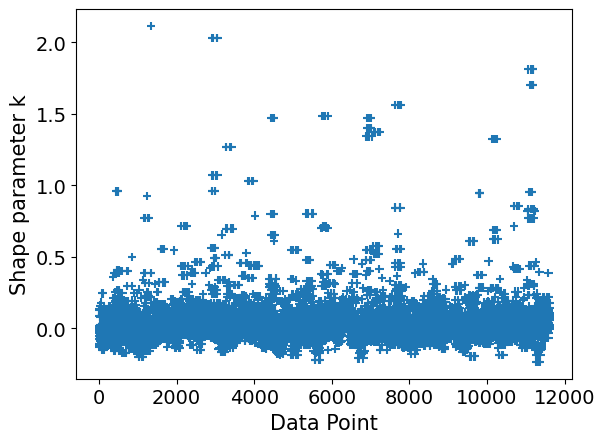

In [3]:
# 1. Diagnose which observations are problematic

model_label ='powerLawEncoding4_regression' # 'risk_regression' #  #model_name = "PLE ∂ev_sd_int & ∂prior_mus + Reg"
idata = az.from_netcdf(op.join(trace_folder, f'model-{model_label}{remove_sub_string}_format{format}_trace.netcdf'))

loo = az.loo(idata, pointwise=True)
az.plot_khat(loo)  # visual overview
# find the bad ones:
import numpy as np
bad_idx = np.where(loo.pareto_k.values > 0.7)[0]

In [4]:
loo = az.loo(idata, pointwise=True)  # PyMC can do moment matching internally
loo

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 11621 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -3990.43    59.81
p_loo      152.72        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     11443   98.5%
 (0.5, 0.7]   (ok)          58    0.5%
   (0.7, 1]   (bad)         63    0.5%
   (1, Inf)   (very bad)    57    0.5%

In [5]:
model_label ='powerLawEncoding3_regression' # 'risk_regression' #  #model_name = "PLE ∂ev_sd_int & ∂prior_mus + Reg"
idata = az.from_netcdf(op.join(trace_folder, f'model-{model_label}{remove_sub_string}_format{format}_trace.netcdf'))
loo = az.loo(idata, pointwise=True)  # PyMC can do moment matching internally
loo

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/arviz/stats/stats.py:803: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.7 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 8000 posterior samples and 11621 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -4068.19    63.32
p_loo      172.73        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)     11354   97.7%
 (0.5, 0.7]   (ok)          43    0.4%
   (0.7, 1]   (bad)        105    0.9%
   (1, Inf)   (very bad)   119    1.0%